When modifying version for Doe:
- Remove any unused code
- Save consolidated dataframes as csvs
- Make it clear where to specify directory where data is stored

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
import matplotlib.dates as mdates


pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', 150)


In [2]:
#Things for plotting
colordict = {'control': "#7F7F7F",
             'below':  "#008000",
             'east': "#DAA520",
             'west': "#87CEEB",
             'south': "#215F9A",
             'other1': "#FF0000",
             'other2': "#C04F15",
             'other3': "#800080"
             }

arraycolor = colordict['other2'] #Color to represent whole array

hh_index = np.arange(0, 24, 0.5)

## Functions

### Quality control and gap filling

In [3]:
#Function to qc (remove qc flag of 2 and values outside specified limits) and gapfill (up to 3 consecutive missing datapoints)
def qc_and_gf(data: pd.Series, qc_flag: pd.Series, minval = float('-inf'), maxval = float('-inf'), gf_gap = 3): #Column containing data to QC, QC flag column, upper limit, lower limit
    data = data.where((data>minval)&(data<maxval))
    if qc_flag is not None:
        data = data.where(qc_flag.isin([0, 1]))
    if gf_gap>0:
        data = data.interpolate('linear', limit = gf_gap)
    return data

### Function for reading in data

In [4]:
#Function for reading in and formatting data
def rnf(filepath, dt_form): # function for reading and formatting dataframes from csv-like file
        
    # Read in file, Create column of datetime objects from the 'TIMESTAMP COLUMN', shift to local standard time
    if dt_form == 'EP_full': #EP full output
        df = pd.read_csv(filepath, header = [1], skiprows= [2]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'EP_AF': #EP AmeriFlux format
        df = pd.read_csv(filepath, header = [17], skiprows= [18]) #read in file
        df['dt_ts'] = pd.to_datetime(df['date']+df['time'], format = '%Y-%m-%d%H:%M') - dt.timedelta(hours = 6)
    elif dt_form == 'BM': #Biomet data
        df = pd.read_csv(filepath, skiprows = [1]) #read in file
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP_1'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 6)
    elif dt_form == 'SB': #Shadowband data
        df = pd.read_csv(filepath, header = 1, skiprows=[2, 3], 
                    dtype = {'TIMESTAMP': str, 'Shadow_Avg':np.float64, 
                             'Clear_Avg':np.float64,'Bar_Avg':np.float64, 'Shadowfiveminavg_Avg':np.float64,
                               'Stot':np.float64, 'Sbeam':np.float64, 'Sdiff':np.float64}, na_values = ['NAN'])
        
        df['dt_ts'] = pd.to_datetime(df['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') - dt.timedelta(hours = 7)
    
    
    df.set_index('dt_ts', inplace = True) #Set dt_ts as index

    if dt_form =='SB':
        df = df.select_dtypes('number').resample('30min').mean() #Resample to 30 minutes (other datasets are already at 30 m freq)
    r = pd.date_range(start=df.index.min(), end=df.index.max(), freq = '30min') #create index without any missing timesteps
    df = df.reindex(r).rename_axis('dt_ts') #Reindex to r (basically fills in missing timesteps with NaNs)


    df = df.map(lambda x: np.nan if x == -9999 else x) #convert -9999 to nan
    return df

### Averaging functions

In [5]:
#functions for averaging data - diel cycle and 1 day average, day average can also be used with different frequency input as avg_time
def day_cyc(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf')):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
    if type(data) == pd.core.frame.DataFrame:
        data = data.select_dtypes('number')
    data = data[sd:ed].where((data>minval)&(data<maxval))
    avg = data.groupby(data.index.time).mean()
    return avg 


# def day_avg(data, sd = 0, ed = 0, minval = float('-inf'), maxval = float('inf'), avg_time = '1d'):
#     if sd == 0:
#         sd = data.index.min()
#     if ed == 0:
#         ed = data.index.max()
#     if type(data) == pd.core.frame.DataFrame:
#         data = data.select_dtypes('number')
#     data = data[sd:ed].where((data>minval)&(data<maxval))
#     avg = data.resample(avg_time).mean()
#     return avg

#Take 7-day average where each half hour of day is weighted evenly (average across days, then across times)
def weighted_week_avg(data, sd = 0, ed = 0, avg_time = '7d'):
    if sd == 0:
        sd = data.index.min()
    if ed == 0:
        ed = data.index.max()
   
    week_avg = data.groupby([pd.Grouper(freq=avg_time), data.index.time]).mean().groupby(level=0).mean()
    week_avg.index = week_avg.index + pd.Timedelta('3.5D')
    return week_avg

## Read in and Process Data

### Read in flux and biomet data

In [6]:
#Read in EP, biomet, and shadowband data
base_dir1 = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\Data\\'

# EddyPro Output data
KSA = rnf(base_dir1 +'EP_Output\\eddypro_KSA_full_output_2025-10-13T202425_adv.csv', dt_form = 'EP_full')
KSC = rnf(base_dir1 + 'EP_Output\\eddypro_KSC_full_output_2025-10-14T092857_adv.csv', dt_form = 'EP_full')

#Biomet data
KSA_bm = rnf(base_dir1 + 'KSA_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)
KSC_bm = rnf(base_dir1 + 'KSC_full_biomet.csv', dt_form = 'BM').drop('TIMESTAMP_1', axis = 1)

#Combine dataframes for each site
sd = dt.datetime(2025, 6, 1)
ed = dt.datetime(2025, 10, 1)
KSA_all = pd.concat([KSA[sd:ed], KSA_bm[sd:ed]], axis = 1)
KSC_all = pd.concat([KSC[sd:ed], KSC_bm[sd:ed]], axis = 1)


### Process and format data
Format as one dataframe for each tower with only the needed columns

In [7]:
#Define dictionary
coldict = {# col name: [qc col name, dataframe (EP or BM), name in new DF, conversion factor, units (after conversion)]
    'co2_flux': ['qc_co2_flux', 'NEE', -50, 50], #CO2 flux
    'h2o_flux': ['qc_h2o_flux', 'ET', -2, 18], #water flux, min and max val are in mmol/m^2/s (units converted after filtering)
    'LE': ['qc_LE', 'LE', -100, 600], #Latent heat flux
    'H': ['qc_H', 'H', -200, 600], #Senisible heat flux
    'SWin': [None, 'SWin', -5, 2000], #shortwave in
    'SWout': [None, 'SWout', -5, 2000], #shortwave out
    'LWin': [None, 'LWin', 50, 600], #longwave in
    'LWout': [None, 'LWout', 100, 750], #longwave out
    'Ta_1_1_1': [None, 'TA1', -50, 50], #Air temperature (TA) at top of tower
    'Ta_1_1_2': [None, 'TA2', -50, 50], #Second TA measurement (only on KSA tower, lower than top)
    'RH_1_1_1': [None, 'RH1', 0, 100], #Relative humidity (RH) at top of tower
    'RH_1_1_2': [None, 'RH2', 0, 100] #Second RH measurement (only on KSA tower, lower than top)
}

In [8]:
#Create empty dataframes to fill
KSA_use = pd.DataFrame()
KSC_use = pd.DataFrame()

#Conversion factor for h2o flux (mmol m-2 s-1) to ET (mm/day)
#mmol/m^2/s * 1mol/1e3mmol * 18g/mol * 1kg/1e3g * 1m^3/1e3kg * 1e3mm/m * 86400s/d = mm/d
ET_cf = 1e-3 * 18 * 1e-3 * 1e-3 * 1e3 * 86400 
#Conversion factor for CO2 flux (micromol m-2 s-1) to NEE (g m-2 day-1)
#micromol/m^2/s * 1mol/1e6micromol * 12gC/mol*86400s/d
NEE_cf = -1 * 1e-6 * 12 * 86400 
 
towdat_dict = {'KSA': [KSA_all, KSA_use], 'KSC': [KSC_all, KSC_use]}
for tow in towdat_dict.keys():
    all_towdat = towdat_dict[tow][0] #DataFrame with all data
    use_towdat = towdat_dict[tow][1] #Empty dataframe to be filled with data to use
    for col in coldict.keys():
        #Pull information from coldict
        if col in all_towdat.columns:
            qc_col_name = coldict[col][0] #Name of qc flag column
            new_var_name = coldict[col][1] #Variable name to use in new dataframe
            minval = coldict[col][2] #Minimum value - remove all lower data points
            maxval = coldict[col][3] #Maximum value - remove all higher data points

            col_data = all_towdat[col] #get data from column in all_towdat
            if qc_col_name is not None: #If given a column name for qc flag column, get that column data
                qc_flag = all_towdat[qc_col_name]
            else:
                qc_flag = None #If no qc flag column name is give, qc_flag is none

            #Run qc and gap filling on column
            # qc_and_gf(data, qc_flag, minval = float('-inf'), maxval = float('-inf'), gf_gap = 3)
            col_data = qc_and_gf(col_data, qc_flag, minval, maxval, gf_gap=5) 

            #For shortwave values less than 0, set to 0
            if col in ['SWin', 'SWout']:
                col_data.map(lambda x: 0 if x <0 else x)[sd:ed]

            if col == 'h2o_flux':
                col_data = col_data*ET_cf

            if col == 'co2_flux':
                col_data = col_data*NEE_cf

            #Set column in new dataframe to processed column data
            use_towdat[new_var_name] = col_data




## Save formatted data as csv

In [9]:
# KSA_use.to_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\AVRF_group\\group_paper\\KSA.csv')
# KSC_use.to_csv('C:\\Users\\emily\\Documents\\Grad_School\\Research\\Solar\\AVRF_group\\group_paper\\KSC.csv')

# Plots

### NEE and ET

Make NEE positive and change untis? #fixthis

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\3621919212.py:4: SyntaxWarning: invalid escape sequence '\ '
  vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\3621919212.py:5: SyntaxWarning: invalid escape sequence '\ '
  'ET': '[$mm \ d^-1$]',


NEE
ET


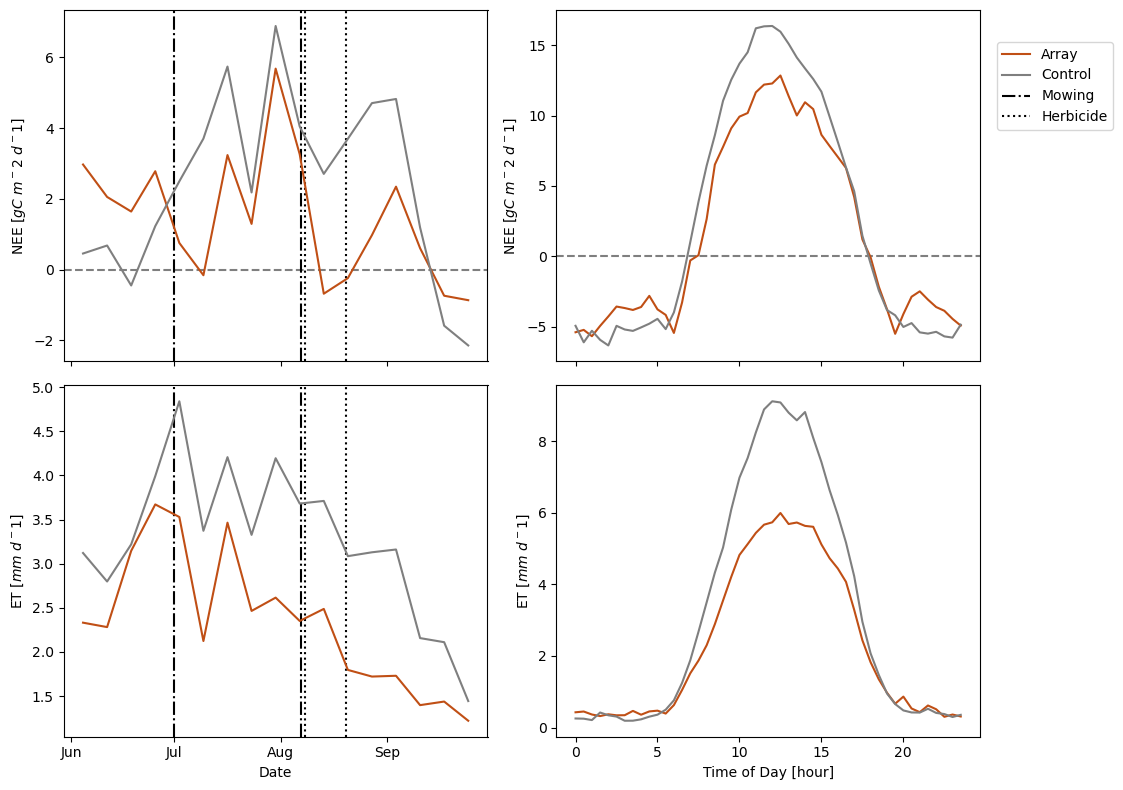

In [10]:
#Flux plots (NEE and ET)

#Dictionary with variable names and units
vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
           'ET': '[$mm \ d^-1$]',
}

#Create plot
figsize = (10, 8)
fig, axs = plt.subplots(2,2,  figsize = figsize, sharex = 'col')

#Add zero line for NEE plots
for ax in axs[0, :]:
    ax.axhline(0, c = 'k', linestyle = '--', alpha = 0.5) #first mowing


#Add management as vertical lines on each plot
for ax in axs[:, 0]:
    # m1 = ax.axvspan(xmin=dt.datetime(2025, 7, 1), xmax=dt.datetime(2025, 7, 3), alpha=0.3, color=colordict['below'])
    # ax.axvspan(xmin=dt.datetime(2025, 8, 4), xmax=dt.datetime(2025, 8, 8), alpha=0.3, color=colordict['below'])
    # m2 = ax.axvspan(xmin=dt.datetime(2025, 8, 8), xmax=dt.datetime(2025, 8, 9), alpha=0.3, color=colordict['other3'])
    m1 = ax.axvline(dt.datetime(2025, 7, 1), color = 'k',linestyle = '-.')
    ax.axvline(dt.datetime(2025, 8, 7), color='k', linestyle = '-.')
    m2 = ax.axvline(dt.datetime(2025, 8, 8), color = 'k',linestyle = ':')
    ax.axvline(dt.datetime(2025, 8, 20), color = 'k',linestyle = ':')


#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(len(vardict.keys())): #Need i for plotting
    var = list(vardict.keys())[i]
    units = vardict[var]
    print(var)

    #Time series plot
    #Select left axis
    axl = axs[i, 0]

    KSA_avg = weighted_week_avg(KSA_use[var])
    KSC_avg = weighted_week_avg(KSC_use[var])
    
    #Plot time series on left axis
    l1 = axl.plot(KSA_avg[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSC_avg[sd:ed], label = 'Control', c = colordict['control'])

    axl.set_ylabel(var  + ' ' + units)

    #Cumulative plot
    #Right axis
    axr = axs[i, 1]

    #calculate cumulative values
    KSA_day_cyc = day_cyc(KSA_use[var])
    KSC_day_cyc = day_cyc(KSC_use[var])

    axr.set_ylabel(var  + ' ' + units)
    

    axr.plot(hh_index, KSA_day_cyc, c = arraycolor)
    axr.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], m1, m2]


axl.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axl.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

#X-axis labels
axl.set_xlabel('Date')
axr.set_xlabel('Time of Day [hour]')

#Add figure legend
fig.legend(handles, ['Array', 'Control', 'Mowing', 'Herbicide'], loc = 'upper right', bbox_to_anchor=(1.125, .95))

#Save figure
save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')

### Energy Balance

### Start here and figure out how to make the stackplot
 - also add measurement heights for the micromet plot

In [11]:
#Create dataframe with weekly average estimated power output
array_area = 6.5e5 #m^2 (6.5 ha)
dtindex_1d = pd.date_range(start = sd, end = ed, freq = '1D') #datetime index with frequency of 1 day
PO_1d = pd.DataFrame(index = dtindex_1d, columns = ['KSA', 'KSC']) #Dataframe with estimated power output, 1 val/day

#Approximate DC power production by array (using PVwatts from NREL)
PO_month = np.array([404/30, 425/31, 419/31, 379/30, 335/31]) #Array of estimated power output divided by days in month for June - October [KWh/day]
PO_month*1e3/24/array_area #[W/m^2] Average rate of energy removed from array for power production


# Adds average power output for each day to the PO_1d dataframe
month_map = {i+6: val for i, val in enumerate(PO_month)} #dictionary of month value: power output value
PO_1d['KSA'] = PO_1d.index.month.map(month_map) #Uses month_map to fill in power_output column of PO_1d
PO_1d['KSC'] = 0
PO_1w = weighted_week_avg(PO_1d)[sd:ed] #resamples to 1 week, timestamp is middle of week
PO_1w.mean()


KSA    13.353782
KSC     0.000000
dtype: float64

KSA 36.39041636788197 0.26190306836646593 23.03663485527692 0.16080652482896832
KSC 8.71355319455277 0.06664166466003733 8.71355319455277 0.06664166466003733


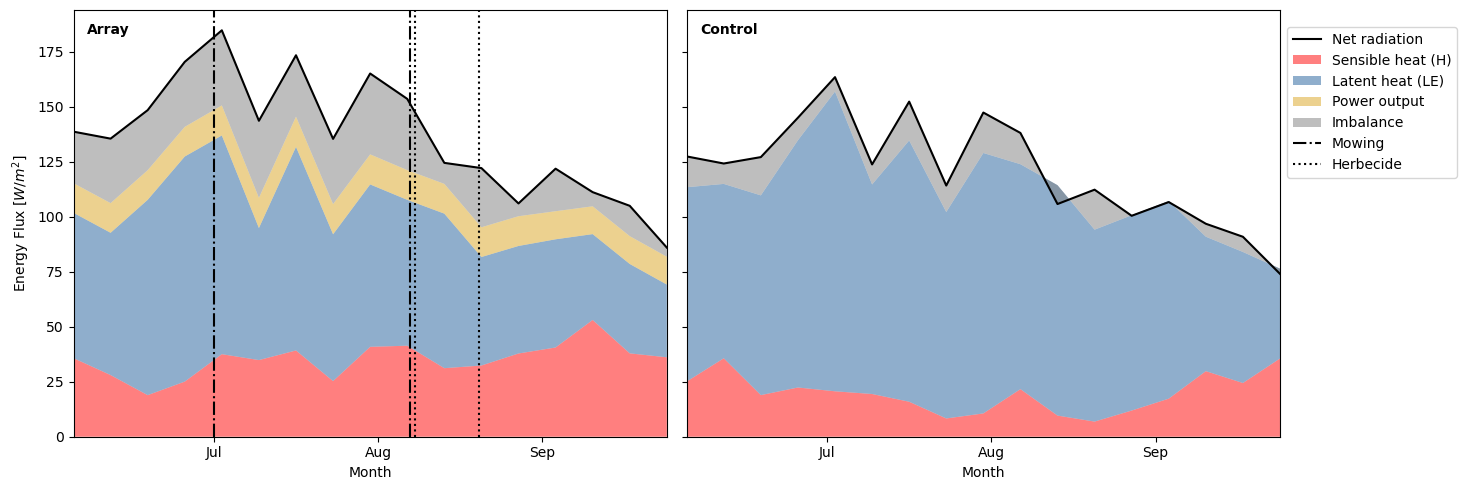

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (13, 5), sharey = 'row')

for i in range(len(axs)):
    ax = axs[i] #select axes
    tow = list(towdat_dict.keys())[i] #select tower
    towdat = towdat_dict[tow] #select data for given tower

    #Calculated values
    towdat_1w = weighted_week_avg(towdat)[sd:ed] #Take one week average of towdat. Date index is center of average week
    RN = towdat_1w['SWin'] + towdat_1w['LWin'] - towdat_1w['SWout'] - towdat_1w['LWout'] #Calculation net radiation

    #Plots
    l1 = ax.plot(RN, c = 'k', label = 'Net radiation') #Plot net radiation as a line
    #Calc avg energy imblance
    Imb_np = (RN - towdat_1w['H'] - towdat_1w['LE'])
    Imb_wp = (RN - towdat_1w['H'] - towdat_1w['LE'] - PO_1w[tow])
    print(tow, Imb_np.mean(), (Imb_np/RN).mean(), Imb_wp.mean(), (Imb_wp/RN).mean())
    #Stacked plot of outgoing energy fluxes (H, LE, power output for array, and energy imbalance)
    sp = ax.stackplot(towdat_1w.index, towdat_1w['H'], towdat_1w['LE'], PO_1w[tow], RN - towdat_1w['H'] - towdat_1w['LE'] - PO_1w[tow],
                 labels = ['Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance'],
                 colors = [colordict['other1'], colordict['south'],colordict['east'], colordict['control']], alpha = 0.5) 
    
    #Format x axis
    ax.set_xlim(towdat_1w.index.min(), towdat_1w.index.max())
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name
    ax.set_xlabel('Month')


#Plot management periods
# axs[0].axvspan(xmin=dt.datetime(2025, 7, 1), xmax=dt.datetime(2025, 7, 3), alpha=0.3, color=colordict['below'], label = 'mowing', zorder = 0)
# axs[0].axvspan(xmin=dt.datetime(2025, 8, 4), xmax=dt.datetime(2025, 8, 8), alpha=0.3, color=colordict['below'], zorder = 0)
# axs[0].axvspan(xmin=dt.datetime(2025, 8, 8), xmax=dt.datetime(2025, 8, 9), alpha=0.3, color=colordict['other3'], label = 'herbecide', zorder = 0)
m1 = axs[0].axvline(dt.datetime(2025, 7, 1), color = 'k',linestyle = '-.', label = 'mowing')
axs[0].axvline(dt.datetime(2025, 8, 7), color='k', linestyle = '-.')
m2 = axs[0].axvline(dt.datetime(2025, 8, 8), color = 'k',linestyle = ':', label = 'herbicide')
axs[0].axvline(dt.datetime(2025, 8, 20), color = 'k',linestyle = ':')


#Shared y axis
axs[0].set_ylabel('Energy Flux [$W/m^2$]')

#Add tower names to each panell
axs[0].annotate('Array', (sd + dt.timedelta(days = 6), 183), weight = 'bold')
axs[1].annotate('Control', (sd + dt.timedelta(days = 6), 183), weight = 'bold')

#Add figure legend 
handles = [l1[0], sp[0], sp[1], sp[2], sp[3], m1, m2]
fig.legend(handles, ['Net radiation', 'Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance', 'Mowing', 'Herbecide'], 
           loc = 'upper right', bbox_to_anchor=(1.13, .95)) #fixthis

plt.tight_layout()
    


KSA 36.39041636788197 0.26190306836646593 23.03663485527692 0.16080652482896832
KSC 8.71355319455277 0.06664166466003733 8.71355319455277 0.06664166466003733


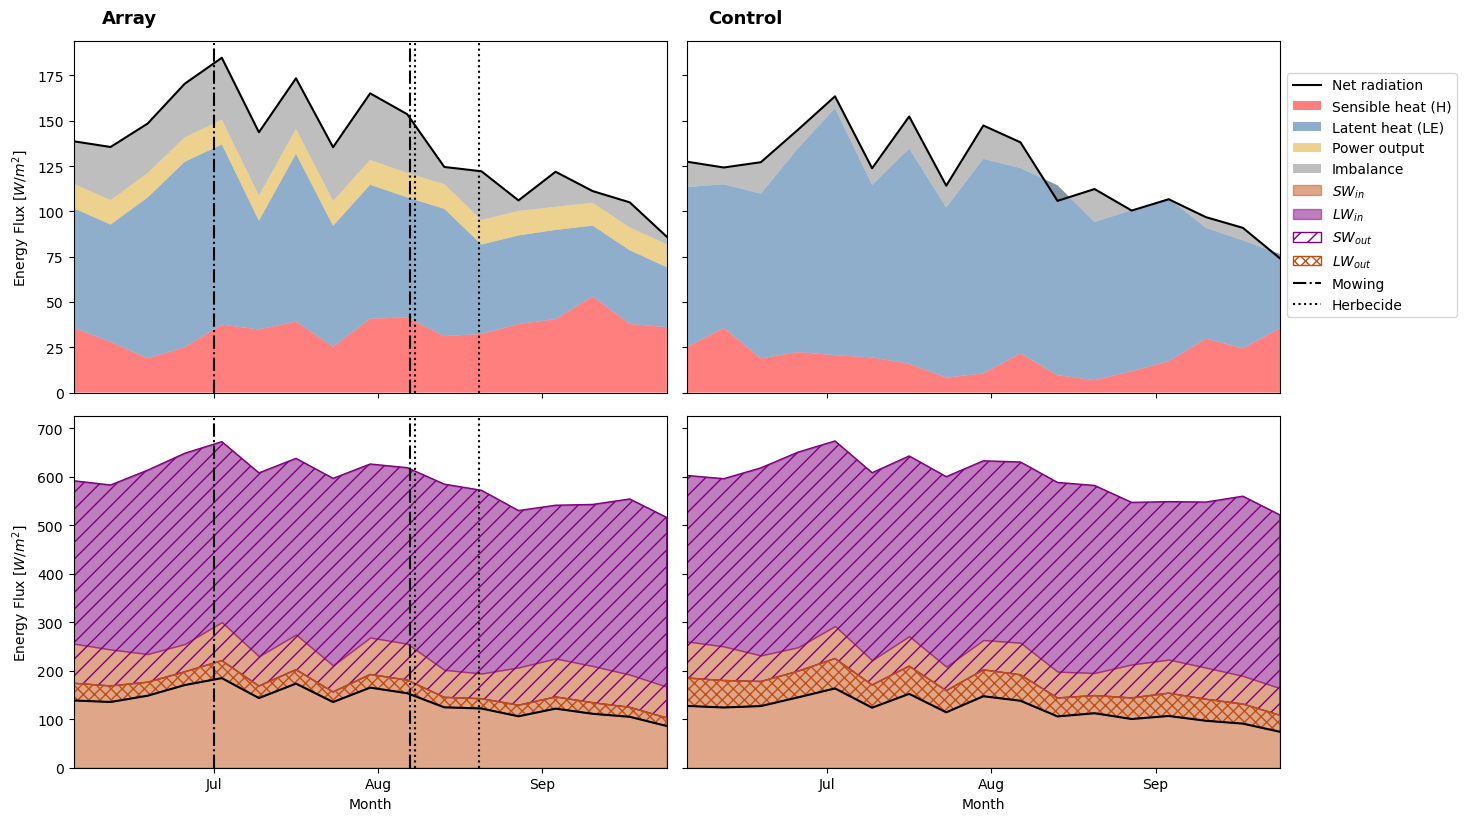

In [ ]:
fig, axs = plt.subplots(2, 2, figsize = (13, 8), sharey = 'row', sharex = 'col')

#Set colors 
Hcolor = colordict['other1'] #senisble heat
LEcolor = colordict['south'] #latent heat
Pcolor = colordict['east'] #Power output
Imbcolor = colordict['control'] #Imbalance
RNcolor = 'black'
SWcolor = colordict['other2'] #shortwave radaition
LWcolor = colordict['other3'] #lonwave radiation 
fillweight = 0.5


#Dictionary of tower data
towdat_dict = {'KSA': KSA_use, 'KSC': KSC_use}
tow_label_list = ['Array', 'Control']

#Loop through towers
for i in range(2):
    tow = list(towdat_dict.keys())[i] #select tower
    tow_label = tow_label_list[i]
    towdat = towdat_dict[tow][1] #select data for given tower
    
    #select top axis in column for energy balance plot(top, column)
    axt = axs[0, i] 


    #Calculated values
    towdat_1w = weighted_week_avg(towdat)[sd:ed] #Take one week average of towdat. Date index is center of average week
    RN = towdat_1w['SWin'] + towdat_1w['LWin'] - towdat_1w['SWout'] - towdat_1w['LWout'] #Calculation net radiation

    '''Energy balance plots'''
    l1 = axt.plot(RN, c = RNcolor, label = 'Net radiation') #Plot net radiation as a line
    #Calc avg energy imblance
    Imb_np = (RN - towdat_1w['H'] - towdat_1w['LE'])
    Imb_wp = (RN - towdat_1w['H'] - towdat_1w['LE'] - PO_1w[tow])
    print(tow, Imb_np.mean(), (Imb_np/RN).mean(), Imb_wp.mean(), (Imb_wp/RN).mean())
    #Stacked plot of outgoing energy fluxes (H, LE, power output for array, and energy imbalance)
    sp = axt.stackplot(towdat_1w.index, towdat_1w['H'], towdat_1w['LE'], PO_1w[tow], RN - towdat_1w['H'] - towdat_1w['LE'] - PO_1w[tow],
                    labels = ['Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance'],
                    colors = [Hcolor, LEcolor, Pcolor, Imbcolor], alpha = fillweight) 




    '''Stacked plot of incoming and outgoing radiation'''
    #select bottom axis in column for radiation plot(top, column)
    axb = axs[1, i] 



    #Calculate fill area borders
    all_in = towdat_1w['SWin']+ towdat_1w['LWin'] #allwave in
    LW_out_base = all_in - towdat_1w['LWout'] #Base of LW_out fill area (allwave in - LWout)
    

    fa1 = axb.fill_between(towdat_1w.index, 0, towdat_1w['SWin'], color=SWcolor, alpha=fillweight, label="$SW_{in}$")
    fa2 = axb.fill_between(towdat_1w.index, towdat_1w['SWin'], all_in, color=LWcolor, alpha=fillweight, label="$LW_{in}$")

    ha1 = axb.fill_between(towdat_1w.index, LW_out_base, all_in, alpha=1, label="$LW_{out}$",
                     hatch = '//', edgecolor = LWcolor, facecolor = 'none')
    ha2 = axb.fill_between(towdat_1w.index, RN, LW_out_base, alpha=1, label="$SW_{out}$",
                     hatch = 'xxx', color = None, edgecolor = SWcolor, facecolor = 'none')
    axb.plot(RN, c = RNcolor, label = 'Net radiation') #Plot net radiation as a line
    
    axb.set_ylim(0, 725) #Set y limits for bottom plot
    
    #Format x axis
    axb.set_xlim(towdat_1w.index.min(), towdat_1w.index.max())
    axb.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
    axb.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name
    axb.set_xlabel('Month')

    #Add site labels to columns
    #There is some weird math with calculating the horizontal position 
    #I think this is because there is no axis label on right panel so the x0 position is off
    x = axt.get_position().x0 + i*(axt.get_position().x0 + axt.get_position().x1)/25
    fig.text(x, 1.01, tow_label, ha="right", va="center", fontsize=13, fontweight="bold")

    #Add vertical lines for management
    for ax in [axt, axb]:
        if tow =='KSA':
            m1 = ax.axvline(dt.datetime(2025, 7, 1), color = 'k',linestyle = '-.', label = 'mowing')
            ax.axvline(dt.datetime(2025, 8, 7), color='k', linestyle = '-.')
            m2 = ax.axvline(dt.datetime(2025, 8, 8), color = 'k',linestyle = ':', label = 'herbicide')
            ax.axvline(dt.datetime(2025, 8, 20), color = 'k',linestyle = ':')

            #Shared y axis
            ax.set_ylabel('Energy Flux [$W/m^2$]')
        

#Add figure legend 
handles = [l1[0], sp[0], sp[1], sp[2], sp[3], fa1, fa2, ha1, ha2, m1, m2]
fig.legend(handles, ['Net radiation', 'Sensible heat (H)', 'Latent heat (LE)', 'Power output', 'Imbalance', '$SW_{in}$','$LW_{in}$','$SW_{out}$','$LW_{out}$', 'Mowing', 'Herbecide'], 
           loc = 'upper right', bbox_to_anchor=(1.13, .95)) 

plt.tight_layout()
    


### TA and RH

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:98: SyntaxWarning: invalid escape sequence '\D'
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\984988335.py:4: SyntaxWarning: invalid escape sequence '\c'
  vardict = {'$T_{air}$': ['TA1', 'TA2', '[$^\circ$C]'],
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\984988335.py:98: SyntaxWarning: invalid escape sequence '\D'
  fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$ (array 2, control)'], bbox_to_anchor=(.88, 1.05), ncol=len(handles))
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\984988335.py:98: SyntaxWarning: invalid escape sequence '\D'
  fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$ (a

$T_{air}$
RH


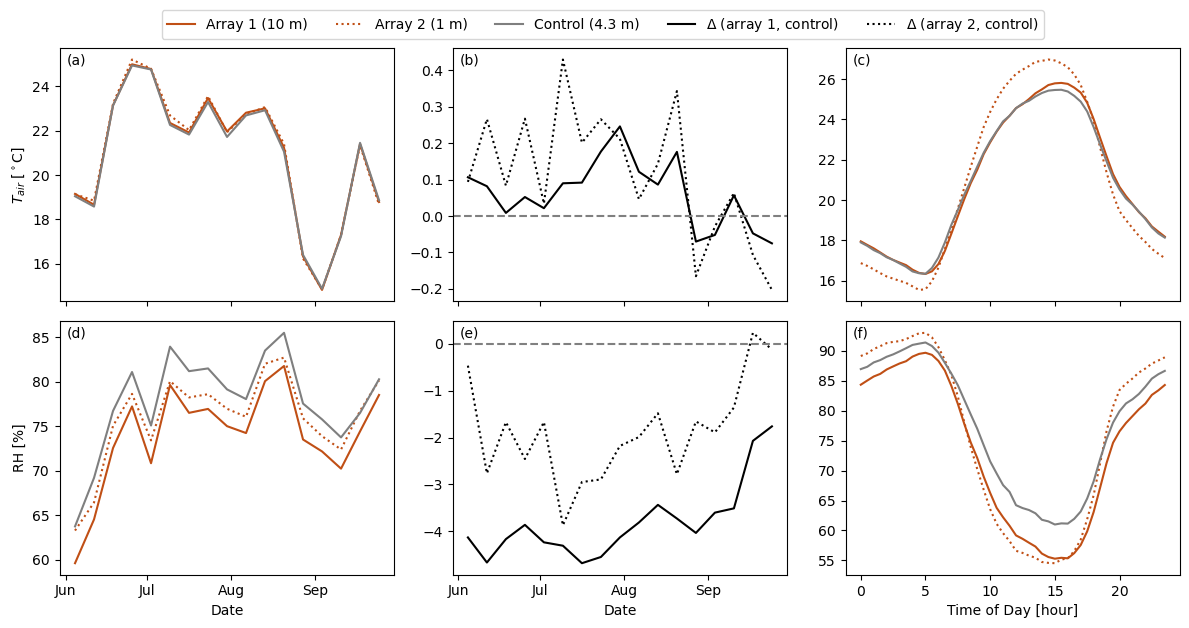

In [14]:
#Micromet - TA and RH plot

#Dictionary with variable names and units
vardict = {'$T_{air}$': ['TA1', 'TA2', '[$^\circ$C]'],
           'RH': ['RH1', 'RH2', '[%]']
}

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

#Create plot
figsize = (12, 6)
fig, axs = plt.subplots(2,3,  figsize = figsize, sharex = 'col')


# #Add management as vertical lines on each plot - not really needed for this plot but could be added back in 
# for ax in axs[:, 0]:
#     m1 = ax.axvspan(xmin=dt.datetime(2025, 7, 1), xmax=dt.datetime(2025, 7, 3), alpha=0.3, color=colordict['below'])
#     ax.axvspan(xmin=dt.datetime(2025, 8, 4), xmax=dt.datetime(2025, 8, 8), alpha=0.3, color=colordict['below'])
#     m2 = ax.axvspan(xmin=dt.datetime(2025, 8, 8), xmax=dt.datetime(2025, 8, 9), alpha=0.3, color=colordict['other3'])


#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(len(vardict.keys())): #Need i for plotting
    var = list(vardict.keys())[i]
    col1 = vardict[var][0]
    col2 = vardict[var][1]
    units = vardict[var][2]
    print(var)

    #Time series plot
    #Select left axis
    axl = axs[i, 0]

    KSA_avg1 = weighted_week_avg(KSA_use[col1])
    KSA_avg2 = weighted_week_avg(KSA_use[col2])
    KSC_avg = weighted_week_avg(KSC_use[col1])
    
    #Plot time series on left axis
    l1 = axl.plot(KSA_avg1[sd:ed], label = 'Array', c = arraycolor)
    l2 = axl.plot(KSA_avg2[sd:ed], label = 'Array', c = arraycolor, linestyle = ':')
    l3 = axl.plot(KSC_avg[sd:ed], label = 'Control', c = colordict['control'])

    axl.set_ylabel(var  + ' ' + units)

    
    #Difference plot
    #select center axis
    axc = axs[i, 1]

    KSA_avg1 = weighted_week_avg(KSA_use[col1])
    KSA_avg2 = weighted_week_avg(KSA_use[col2])
    KSC_avg = weighted_week_avg(KSC_use[col1])
    
    #Plot time series on left axis
    l4 = axc.plot(KSA_avg1[sd:ed] - KSC_avg[sd:ed], label = 'Array', c = 'k')
    l5 = axc.plot(KSA_avg2[sd:ed] - KSC_avg[sd:ed], label = 'Array', c = 'k', linestyle = ':')
    axc.axhline(0, linestyle = '--', c= 'gray')

    axl.set_ylabel(var  + ' ' + units)

    #Cumulative plot
    #Right axis
    axr = axs[i, 2]

    #calculate cumulative values
    KSA_day_cyc1 = day_cyc(KSA_use[col1])
    KSA_day_cyc2 = day_cyc(KSA_use[col2])
    KSC_day_cyc = day_cyc(KSC_use[col1])

    # axr.set_ylabel(var  + ' ' + units)
    

    axr.plot(hh_index, KSA_day_cyc1, c = arraycolor)
    axr.plot(hh_index, KSA_day_cyc2, c = arraycolor, linestyle = ':')
    axr.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0], l3[0], l4[0], l5[0]]

for j in range(len(axs.flatten())):
    ax = axs.flatten()[j]
    ax.annotate(labels[j], (.02, .935), xycoords = 'axes fraction')

#Set x axes labels as month names
axl.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axl.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name
axc.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
axc.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

#X-axis labels
axl.set_xlabel('Date')
axc.set_xlabel('Date')
axr.set_xlabel('Time of Day [hour]')

#Add figure legend
fig.legend(handles, ['Array 1 (10 m)', 'Array 2 (1 m)', 'Control (4.3 m)', '$\Delta$ (array 1, control)', '$\Delta$ (array 2, control)'], bbox_to_anchor=(.88, 1.05), ncol=len(handles))

#Save figure
save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')

## Seasonal averages

In [15]:
(KSC_use.mean() - KSA_use.mean())/KSC_use.mean()

ET       0.279550
H       -0.764461
LE       0.287065
LWin     0.023246
LWout    0.000325
NEE      0.358623
RH1      0.048423
RH2           NaN
SWin    -0.008168
SWout    0.469836
TA1     -0.002778
TA2           NaN
dtype: float64

In [16]:
(KSC_use.RH1 - KSA_use.RH2).mean(), (KSC_use.RH1 - KSA_use.RH1).mean()

(np.float64(1.7678434636617153), np.float64(3.7556240396107228))

In [17]:
1 - (5857 - KSA_use.count())/ 5857, 1 - (5857 - KSC_use.count())/ 5857

(NEE      0.988219
 ET       0.989585
 LE       0.990097
 H        0.998805
 SWin     1.000000
 SWout    1.000000
 LWin     1.000000
 LWout    1.000000
 TA1      1.000000
 TA2      1.000000
 RH1      1.000000
 RH2      1.000000
 dtype: float64,
 NEE      0.986683
 ET       0.988390
 LE       0.988390
 H        0.992658
 SWin     1.000000
 SWout    1.000000
 LWin     1.000000
 LWout    1.000000
 TA1      1.000000
 RH1      1.000000
 dtype: float64)

In [18]:
((KSA_use.TA1 - KSC_use.TA1)**2).mean()**1/2, ((KSA_use.TA2 - KSC_use.TA1)**2).mean()**1/2

(np.float64(0.11482227283592282), np.float64(0.9779645634413879))

In [19]:
KSC_EI = KSC_use.SWin + KSC_use.LWin - KSC_use.SWout - KSC_use.LWout - KSC_use.H - KSC_use.LE
KSA_EI_np = KSA_use.SWin + KSA_use.LWin - KSA_use.SWout - KSA_use.LWout  - KSA_use.H - KSA_use.LE
KSA_EI_wp = KSA_use.SWin + KSA_use.LWin - KSA_use.SWout - KSA_use.LWout  - KSA_use.H - KSA_use.LE


# figure for CCR-SAGE Talk

<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\2429799326.py:4: SyntaxWarning: invalid escape sequence '\ '
  vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\2429799326.py:5: SyntaxWarning: invalid escape sequence '\ '
  'LE': '[$W \ m^2$]',
C:\Users\emily\AppData\Local\Temp\ipykernel_29200\2429799326.py:6: SyntaxWarning: invalid escape sequence '\ '
  'H': '[$W \ m^2$]'


NEE
LE
H


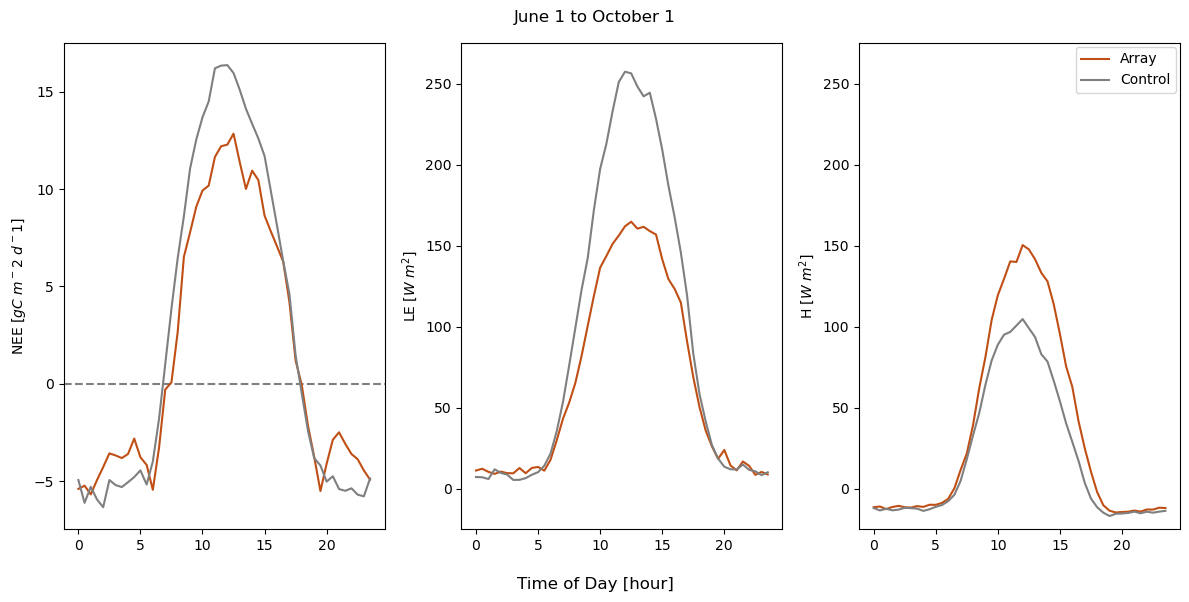

In [20]:
#Flux plots (NEE and ET)

#Dictionary with variable names and units
vardict = {'NEE': '[$gC \ m^-2 \ d^-1$]',
           'LE': '[$W \ m^2$]',
           'H': '[$W \ m^2$]'
}

#Create plot
figsize = (12, 6)
fig, axs = plt.subplots(1,3,  figsize = figsize, sharex = 'col')

#Add zero line for NEE plots
axs[0].axhline(0, c = 'k', linestyle = '--', alpha = 0.5) #first mowing


#Loop through variables, plot time series and cumulative plot for each
handles = [] #Empty list - later filled with legend labels
for i in range(len(vardict.keys())): #Need i for plotting
    var = list(vardict.keys())[i]
    units = vardict[var]
    print(var)

    #Select axis
    ax = axs[i]

    #calculate cumulative values
    KSA_day_cyc = day_cyc(KSA_use[var])
    KSC_day_cyc = day_cyc(KSC_use[var])

    ax.set_ylabel(var  + ' ' + units)
    

    l1 = ax.plot(hh_index, KSA_day_cyc, c = arraycolor)
    l2 = ax.plot(hh_index, KSC_day_cyc, c = colordict['control'])
   

    if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
        handles = [l1[0], l2[0]]

axs[1].set_ylim(-25, 275)
axs[2].set_ylim(-25, 275)

fig.supxlabel('Time of Day [hour]')
fig.suptitle('June 1 to October 1')

#Add figure legend
fig.legend(handles, ['Array', 'Control'], loc = 'upper right', bbox_to_anchor=(.99, .93))

#Save figure
save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
fig.tight_layout()
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
plt.savefig(save_base_path + 'flux_diel_cyc.png', bbox_inches='tight')

# Code Junkyard

In [21]:
# #Code from for plotting each separately with details about unit conversions

# #CO2 Flux
# varname = 'NEE'
# varname_short = varname
# cum_units = '[$g/m^2$]'
# var = 'co2_flux'
# min_val = -100 #From DFC limits(from AFlux?)
# max_val = 100 #From DFC limits(from AFlux?)
# unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

# #H2O flux
# varname = 'Evapotranspiration'
# varname_short = 'ET'
# cum_units = '[$mm$]'
# var = 'h2o_flux'
# LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# min_val = -100*LE_cf# DFC limits(from Ankur)
# max_val = 700*LE_cf #From DFC limits (from Ankur)
# unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor

#Alternate for presenting ET in mm/day
# LE_cf = 1/2.5e3 * 1/1000 * 1/1000 * 1000 * 60 * 60 * 24 #[W/m^2] 


# #H Flux
# varname = 'Sensible Heat Flux'
# varname_short = 'H'
# cum_units = '[$MJ/m^2$]'
# var = 'H'
# min_val = -100 #From DFC limits(from AFlux?)
# max_val = 700 #From DFC limits(from AFlux?)
# unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

In [22]:
# #Cumulative plot - 3 panels

# #Change dates and variable
# sd = dt.datetime(2025,6,1)
# ed = dt.datetime(2025, 10, 1)
# edex = dt.datetime(2025, 10, 2)

# #[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
# vardict = {'NEE': ['NEE', 'co2_flux', '[$\mu mol \ m^-2 \ s^-1$]','[$g \ m^-2$]', 1, -100, 100, 60 * 30 * 1e-6 * 44],
#            'Evapotranspiration': ['ET', 'h2o_flux', '[$mmol \ m^-2 \ s^-1$]','[$mm$]', 1/2.5e3 * 1/18 * 1000, -100, 700, 60 * 30 * 1e-3 * 18 *1e-3],
#            'Sensible Heat Flux': ['H', 'H', '$[W \ m^-2$]','[$MJ \ m^-2$]', 1, -100, 700, 60 * 30 * 1e-6]
# }

# #notes on unit conversions
# # CO2
# # unit_conv = 60 * 30 * 1e-6 * 44 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2
# # H2O
# # LE_cf = 1/2.5e3 * 1/1000 * 1/1000 * 1000 * 60 * 60 * 24 #[W/m^2] 
# # LE_cf =  1/2.5e3 * 1/18 * 1000 #convert LE [W/m^2] to h2o flux [mmol/m^2/s] = 1/Latend heat of vaporization at 0C = 1/2.5e3 J/g * 1/1 mol/18 g* 1000mmol/mol
# # unit_conv = 60 * 30 * 1e-3 * 18 *1e-3#[mmol/m^2/s] * 60 s/min * 30 min * 1 mol/10^3 mmol * 18 g/mol * 1kg/1000g * 1m^3/1000kg * 1000mm/m = [mm]- water vapor
# # H
# # unit_conv = 60 * 30 * 1e-6 #[micromol/m^2/s] * 60 s/min * 30 min * 1 mol/10^6 micromol * 44 g/mol  - CO2

# #Create plot
# figsize = (10,8)
# fig, axs = plt.subplots(3,2,  figsize = figsize, sharex=True)

# #Add management as vertical lines on each plot
# for ax in axs.flatten():
#     m1 = ax.axvline(dt.datetime(2025, 7, 2), c = 'k', linestyle = ':', label = 'Mowing') #first mowing
#     ax.axvline(dt.datetime(2025, 8, 5), c = 'k', linestyle = ':') #Second mowing
#     m2 = ax.axvline(dt.datetime(2025, 8, 8), c = 'k', linestyle = '-.', label = 'Herbicide') #Herbacide


# #Loop through variables, plot time series and cumulative plot for each
# handles = [] #Empty list - later filled with legend labels
# for i in range(3):

#     var = list(vardict.keys())[i] #Long var name
#     varname_short = vardict[var][0] #Shortened var name
#     col = vardict[var][1] #column name in dataframe
#     reg_units = vardict[var][2] #Units
#     cum_units = vardict[var][3] #Units for cumulative plot
#     ETtoLE = 1/vardict[var][4] #Conversion factor for converting between water flux units
#     min_val = vardict[var][4]*vardict[var][5] #Min value for filtering
#     max_val = vardict[var][4]*vardict[var][6] #Max val for filtering
#     units_conv = vardict[var][7] #unit regular to cumulative units conversion factor - see code comments above for where these values come from

#     #Filter based on min and max vals
#     val_filter = (KSA[col]>=min_val) & (KSA[col]<=max_val) & (KSC[col]>=min_val) & (KSC[col]<=max_val)
    
#     #Time series plot
#     #Select left axis
#     axl = axs[i, 0]

#     #
#     KSA_1dayavg = day_avg(KSA[col].where(val_filter), avg_time = '1d')
#     KSC_1dayavg = day_avg(KSC[col].where(val_filter), avg_time = '1d')

#     #Plot time series on left axis
#     l1 = axl.plot(KSA_1dayavg[sd:ed], label = 'Array', c = arraycolor)
#     l2 = axl.plot(KSC_1dayavg[sd:ed], label = 'Control', c = colordict['control'])

#     axl.set_ylabel( varname_short  + ' ' + reg_units)

#     #Cumulative plot
#     #Right axis
#     axr = axs[i, 1]

#     #calculate cumulative values
#     KSA_cum = KSA[col].where(val_filter)[sd:ed].cumsum()*units_conv
#     KSC_cum = KSC[col].where(val_filter)[sd:ed].cumsum()*units_conv
#     # ax.plot(KSA_cum)
#     # ax.plot(KSC_cum)

#     axr.set_ylabel('Cumulative ' + varname_short  + ' ' + cum_units)
    

#     axr.plot(KSA_cum, label = 'Array', c = arraycolor)
#     axr.plot(KSC_cum, label = 'Control', c = colordict['control'])
#     print(varname_short, KSA_cum[-1]/KSC_cum[-1])

#     if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
#         handles = [l1[0], l2[0], m1, m2]

# for ax in [axl, axr]:
#     ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name

# # #Rotate tick labels
# # for tick in axr.get_xticklabels():
# #     tick.set_rotation(45)
# # for tick in axl.get_xticklabels():
# #     tick.set_rotation(45)
# fig.supxlabel('Date')
# # fig.suptitle('Fluxes June 1-October 1 2025')

# #Add figure legend
# fig.legend(handles, ['Array', 'Control', 'Mowing', 'Herbicide'], loc = 'upper right', bbox_to_anchor=(1.125, .95))

# #Save figure
# save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
# fig.tight_layout()
# # plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
# plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches='tight')

In [23]:
# Setup data
#Dates for averaging
# sd = dt.datetime(2025, 7, 28)
# ed = dt.datetime(2025, 8, 5)
# sd = dt.datetime(2025, 6, 1)
# ed = dt.datetime(2025, 10, 1)
# ed_ex = ed + dt.timedelta(days = 5) #extended datetime (needed for multi-day avg) 

# #Set negative radiation values to 0
# sb = sb.map(lambda x: 0 if x <0 else x)[sd:ed_ex]
# Sdir_frac = sb.Sbeam/sb.Stot #Ratio of beam to total
# Sdir_frac = Sdir_frac.where(Sdir_frac<=1)
# KSA_SWin = KSA_bm['SWin'].map(lambda x: 0 if x <0 else x)[sd:ed_ex]
# KSA_flux = KSA[['co2_flux', 'h2o_flux']][sd:ed_ex]
# KSC_flux = KSC[['co2_flux', 'h2o_flux']][sd:ed_ex]

#Diel cycle
# sb_day_cyc = day_cyc(sb, sd, ed, 0, 1300) #average diel cycle of sb data
# Sdir_frac_day_cyc = sb_day_cyc.Sbeam/sb_day_cyc.Stot
# Sdir_frac_day_cyc = Sdir_frac_day_cyc.where(Sdir_frac_day_cyc<1)
# KSA_bm_day_cyc = day_cyc(KSA_SWin, sd, ed)

#1-day avg
# avg_per = '1d'
# # sb_day_avg = day_avg(sb, sd, ed_ex, 0, 1300, avg_time = avg_per) #sb data
# # Sdir_frac_day_avg = sb_day_avg.Sbeam/sb_day_avg.Stot #Ratio of beam to total
# # Sdir_frac_day_avg = Sdir_frac_day_avg.where(Sdir_frac_day_avg<=1)
# KSA_SWin_day_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data
# KSA_flux_day_avg = day_avg(KSA_flux, sd, ed, avg_time = avg_per)
# KSC_flux_day_avg = day_avg(KSC_flux, sd, ed, avg_time = avg_per)


# #multi-day avg
# avg_per = '3d'
# sb_xday_avg = day_avg(sb, sd, ed_ex, 0, 1300, avg_time = avg_per) #sb data
# Sdir_frac_xday_avg = sb_xday_avg.Sbeam/sb_xday_avg.Stot #Ratio of beam to total
# Sdir_frac_xday_avg = Sdir_frac_xday_avg.where(Sdir_frac_xday_avg<=1) #Get rid of any timesteps where direct frac >1
# KSA_SWin_xday_avg = day_avg(KSA_SWin, sd, ed_ex, avg_time = avg_per) #KSA biomet data


In [24]:
# #Micromet Plot - 3 panels

# #Change dates and variable
# sd = dt.datetime(2025,6,1)
# ed = dt.datetime(2025, 10, 1)
# edex = dt.datetime(2025, 10, 2)

# #[short var name, var name in dataframe, units, LE conversion factor, min val, max val, unit conversion for cumulative]
# vardict = {'$T_{air}$': '[C]',
#            'RH' : '[%]'
# }


# #Create plot
# figsize = (10,8)
# fig, axs = plt.subplots(2, 3,  figsize = figsize, sharex=True)

# #Loop through variables, plot time series for each
# handles = [] #Empty list - later filled with legend labels
# for i in range(len(vardict.keys())):

#     var = list(vardict.keys())[i] #Long var name
#     col = vardict[var][0] #column name in dataframe



#     #Filter based on min and max vals
#     val_filter = (KSA[col]>=min_val) & (KSA[col]<=max_val) & (KSC[col]>=min_val) & (KSC[col]<=max_val)
    
#     ax = axs[i]

#     KSA_1dayavg = day_avg(KSA[col].where(val_filter), avg_time = '1d')
#     KSC_1dayavg = day_avg(KSC[col].where(val_filter), avg_time = '1d')


#     l1 = ax.plot(KSA_1dayavg[sd:ed], label = 'Array', c = arraycolor)
#     l2 = ax.plot(KSC_1dayavg[sd:ed], label = 'Control', c = colordict['control'])

#     ax.set_ylabel( var  + ' ' + reg_units) 


#     if not handles: #handles is a list which returns false if empty (if empty, then include values l1 and l2)
#         handles = [l1[0], l2[0]]



# # Format x-axis to show only month names at the start of each month
# for ax in axs:
#     ax.xaxis.set_major_locator(mdates.MonthLocator())  # Tick at start of each month
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as abbreviated month name


# fig.supxlabel('Date')
# # fig.suptitle('Micrometeorology June 1-October 1 2025')

# #Add figure legend
# fig.legend(handles, ['Array', 'Control'], loc = 'upper right', bbox_to_anchor=(.97, .97))

# save_base_path = r'C:\Users\emily\Documents\Grad_School\Research\Solar\Figures\AVRF_manuscript\\'
# fig.tight_layout()

# # plt.savefig(save_base_path + 'all_flux_plots.png', bbox_inches=Bbox([[0,-.2],figsize]))
# plt.savefig(save_base_path + 'micromet.png', bbox_inches='tight')

In [25]:
# #Tomorrow: Move colorbar
# #Idea for later: make this more like heat map with average flux values in each box rather than individual dots

# fig, axs = plt.subplots(1, 2, figsize = (10, 5))
# sdc = dt.datetime(2025, 7, 15)
# edc = dt.datetime(2025, 9, 15)

# quant_cut = 0.05

# flux_diff = KSA_flux-KSC_flux
# filter = KSA_SWin[sdc:edc]>100

# ax = axs[0]
# var = 'co2_flux'
# im = ax.scatter(KSA_SWin[sdc:edc][filter], 
#         1-Sdir_frac[sdc:edc][filter], 
#         c = flux_diff[var][sdc:edc][filter],
#         s = 12,
#         cmap = 'viridis',
#         vmin = flux_diff[var].quantile(quant_cut),
#         vmax = flux_diff[var].quantile(1-quant_cut))
# # ax.set_title('CO2 Flux Difference')
# cax = fig.add_axes([0.105, -.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation = 'horizontal', cax = cax)
# cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

# ax = axs[1]
# var = 'h2o_flux'
# im = ax.scatter(KSA_SWin[sdc:edc][filter], 
#         1-Sdir_frac[sdc:edc][filter], 
#         c = flux_diff[var][sdc:edc][filter],
#         s = 12,
#         cmap = 'viridis',
#         vmin = flux_diff[var].quantile(quant_cut),
#         vmax = flux_diff[var].quantile(1-quant_cut))
# # ax.set_title('H2O Flux Difference')
# cax = fig.add_axes([0.575, -.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation = 'horizontal', cax = cax)
# cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')


# fig.supylabel('Diffuse Fraction')
# fig.supxlabel('$SW_{in}$ [$W/m^2$]')
# fig.tight_layout()
# # cbar_ax = fig.add_axes([.92, 0.15, 0.02, 0.7])
# # plt.colorbar(cb, cbar_ax, label = 'CO2 flux [$\mu mol/{m^2 s}$]')
# plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')

In [26]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# sdc = dt.datetime(2025, 7, 15)
# edc = dt.datetime(2025, 9, 15)

# quant_cut = 0.05

# flux_diff = KSA_flux - KSC_flux
# filter = KSA_SWin[sdc:edc] > 100

# # Define number of bins for the heat map
# n_bins_x = 15
# n_bins_y = 15
# min_points = 5

# # Prepare data
# x_data = KSA_SWin[sdc:edc][filter].values
# y_data = (1 - Sdir_frac[sdc:edc][filter]).values

# # CO2 flux
# ax = axs[0]
# var = 'co2_flux'
# z_data = flux_diff[var][sdc:edc][filter].values

# # Create 2D bins
# x_bins = np.linspace(x_data.min(), x_data.max(), n_bins_x + 1)
# y_bins = np.linspace(y_data.min(), y_data.max(), n_bins_y + 1)

# # Calculate average values and counts in each bin
# z_mean = np.full((n_bins_y, n_bins_x), np.nan)
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
#                 (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
#         if mask.sum() >= min_points:
#             z_mean[j, i] = z_data[mask].mean()

# # Create heat map
# vmin = np.nanquantile(z_data, quant_cut)
# vmax = np.nanquantile(z_data, 1 - quant_cut)
# im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
#                extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
#                vmin=vmin, vmax=vmax)

# cax = fig.add_axes([0.105, -0.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation='horizontal', cax=cax)
# cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

# # H2O flux
# ax = axs[1]
# var = 'h2o_flux'
# z_data = flux_diff[var][sdc:edc][filter].values

# # Calculate average values in each bin
# z_mean = np.full((n_bins_y, n_bins_x), np.nan)
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
#                 (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
#         if mask.sum() >= min_points:
#             z_mean[j, i] = z_data[mask].mean()

# vmin = np.nanquantile(z_data, quant_cut)
# vmax = np.nanquantile(z_data, 1 - quant_cut)
# im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
#                extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
#                vmin=vmin, vmax=vmax)

# cax = fig.add_axes([0.575, -0.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation='horizontal', cax=cax)
# cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')

# fig.supylabel('Diffuse Fraction')
# fig.supxlabel('$SW_{in}$ [$W/m^2$]')
# fig.tight_layout()
# plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')

In [27]:
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# sdc = dt.datetime(2025, 7, 15)
# edc = dt.datetime(2025, 9, 15)

# quant_cut = 0.05

# flux_diff = KSA_flux - KSC_flux
# filter = KSA_SWin[sdc:edc] > 100

# # Define number of bins for the heat map
# n_bins_x = 15
# n_bins_y = 15
# min_points = 5

# # Prepare data
# x_data = KSA_SWin[sdc:edc][filter].values
# y_data = (1 - Sdir_frac[sdc:edc][filter]).values

# # Create 2D bins
# x_bins = np.linspace(x_data.min(), x_data.max(), n_bins_x + 1)
# y_bins = np.linspace(y_data.min(), y_data.max(), n_bins_y + 1)

# # CO2 flux
# ax = axs[0]
# var = 'co2_flux'
# z_data = flux_diff[var][sdc:edc][filter].values

# # Calculate average values and counts in each bin
# z_mean = np.full((n_bins_y, n_bins_x), np.nan)
# counts = np.zeros((n_bins_y, n_bins_x), dtype=int)
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
#                 (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
#         counts[j, i] = mask.sum()
#         if counts[j, i] >= min_points:
#             z_mean[j, i] = z_data[mask].mean()

# # Create heat map
# vmin = np.nanquantile(z_data, quant_cut)
# vmax = np.nanquantile(z_data, 1 - quant_cut)
# im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
#                extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
#                vmin=vmin, vmax=vmax)

# # Add text annotations with counts
# x_centers = (x_bins[:-1] + x_bins[1:]) / 2
# y_centers = (y_bins[:-1] + y_bins[1:]) / 2
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         if counts[j, i] > 0:
#             ax.text(x_centers[i], y_centers[j], str(counts[j, i]),
#                    ha='center', va='center', fontsize=6, color='k')

# cax = fig.add_axes([0.105, -0.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation='horizontal', cax=cax)
# cb.set_label('CO$_2$ flux difference [$\mu mol\ m^{-2}\ s^{-1}$]')

# # H2O flux
# ax = axs[1]
# var = 'h2o_flux'
# z_data = flux_diff[var][sdc:edc][filter].values

# # Calculate average values and counts in each bin
# z_mean = np.full((n_bins_y, n_bins_x), np.nan)
# counts = np.zeros((n_bins_y, n_bins_x), dtype=int)
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         mask = ((x_data >= x_bins[i]) & (x_data < x_bins[i + 1]) &
#                 (y_data >= y_bins[j]) & (y_data < y_bins[j + 1]))
#         counts[j, i] = mask.sum()
#         if counts[j, i] >= min_points:
#             z_mean[j, i] = z_data[mask].mean()

# vmin = np.nanquantile(z_data, quant_cut)
# vmax = np.nanquantile(z_data, 1 - quant_cut)
# im = ax.imshow(z_mean, origin='lower', aspect='auto', cmap='viridis',
#                extent=[x_data.min(), x_data.max(), y_data.min(), y_data.max()],
#                vmin=vmin, vmax=vmax)

# # Add text annotations with counts
# for i in range(n_bins_x):
#     for j in range(n_bins_y):
#         if counts[j, i] > 0:
#             ax.text(x_centers[i], y_centers[j], str(counts[j, i]),
#                    ha='center', va='center', fontsize=6, color='k')

# cax = fig.add_axes([0.575, -0.05, 0.37, 0.02])
# cb = plt.colorbar(im, orientation='horizontal', cax=cax)
# cb.set_label('H$_2$O flux difference [$mmol\ m^{-2}\ s^{-1}$]')

# fig.supylabel('Diffuse Fraction')
# fig.supxlabel('$SW_{in}$ [$W/m^2$]')
# fig.tight_layout()
# plt.savefig(save_base_path + 'SWin_dirfrac_and_flux.png')